# Block Solver: Heterogeneous Cubes in a Marine Layered Model

Space-filling cubic inclusions ($d = 2a$, cubes touching) embedded in a
sedimentary layer, with an ocean surface layer above.

We validate the block-preconditioned Foldy-Lax solver against a dense
reference solve (explicit matrix construction), then use the dressed
T-matrix in the Riccati interlayer solver for ocean-bottom reflectivity.

1. **Marine model** — ocean + 2 sediment layers + basement
2. **Heterogeneity** — moderate cubic inclusions in the target layer
3. **Block solver validation** — exact agreement with dense reference solve
4. **Slab thickness sweep** — $T_{\mathrm{comp}}$ vs $N_z$
5. **Reflectivity** — bare vs dressed T in the Riccati solver

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import LinearOperator, gmres

%matplotlib inline

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

ms_root = Path("/Users/tod/Desktop/MultipleScatteringCalculations")
if str(ms_root) not in sys.path:
    sys.path.insert(0, str(ms_root))

In [2]:
from Kennett_Reflectivity.taup_inversion import _LATEX_RCPARAMS
from Kennett_Reflectivity.layer_model import LayerModel
from cubic_scattering import (
    MaterialContrast, ReferenceMedium, SlabGeometry,
    compute_cube_tmatrix, compute_slab_tmatrices, uniform_slab_material,
)
from cubic_scattering.resonance_tmatrix import (
    _build_incident_field_coupled, _propagator_block_9x9,
    _sub_cell_tmatrix_9x9,
)
from GlobalMatrix.block_riccati_cluster import (
    cluster_from_slab, decompose_layers,
    build_intralayer_fft_kernel, build_interlayer_kernel_cache,
    layered_matvec, _reorder_flat,
)
from GlobalMatrix.dressed_tmatrix import dressed_layer_tmatrix
from GlobalMatrix.interlayer_ms import (
    ScattererSlab9x9, interlayer_ms_reflectivity_9x9,
)

plt.rcParams.update(_LATEX_RCPARAMS)
BLUE, RED, GREEN = "#2980b9", "#c0392b", "#27ae60"

## 1. Marine Layer Model

Four layers: ocean ($\beta = 0$) + soft sediment + target sediment + basement.
Heterogeneous cubes are embedded in the target sediment layer
(interfaces 1 and 2).

In [3]:
model = LayerModel.from_arrays(
    alpha=[1.5, 2.0, 3.0, 5.0],
    beta=[0.0, 0.8, 1.5, 2.8],
    rho=[1.0, 1.8, 2.5, 3.0],
    thickness=[1.0, 0.5, 1.0, np.inf],
    Q_alpha=[20000, 200, 200, 200],
    Q_beta=[1e10, 200, 200, 200],
)
print(f"Model: {model.n_layers} layers")
print("  0: ocean         \u03b1=1.5, \u03b2=0.0 km/s")
print("  1: soft sediment  \u03b1=2.0, \u03b2=0.8 km/s")
print("  2: target sed.    \u03b1=3.0, \u03b2=1.5 km/s  \u2190 heterogeneities")
print("  3: basement       \u03b1=5.0, \u03b2=2.8 km/s")
print(f"\nScatterer interfaces: [1, 2]  (range [1, {model.n_layers - 2}])")

Model: 4 layers
  0: ocean         α=1.5, β=0.0 km/s
  1: soft sediment  α=2.0, β=0.8 km/s
  2: target sed.    α=3.0, β=1.5 km/s  ← heterogeneities
  3: basement       α=5.0, β=2.8 km/s

Scatterer interfaces: [1, 2]  (range [1, 2])


## 2. Heterogeneity Parameters

Space-filling cubes ($d = 2a$) of a harder material embedded in the
target sediment.  The reference medium for the cube T-matrix is the
host sediment (SI units: m/s, kg/m³).

We use a **moderate contrast** for the block solver validation
(GMRES converges rapidly) and a **hard contrast** for the reflectivity
section (which only requires the dressed T-matrix, not the full
Foldy-Lax solve).

In [4]:
# Host sediment (SI units)
ref = ReferenceMedium(alpha=3000.0, beta=1500.0, rho=2500.0)

# Moderate contrast for block solver validation
contrast_mod = MaterialContrast(Dlambda=3.0e9, Dmu=1.5e9, Drho=100.0)

# Hard contrast for reflectivity (dressed T only, no block solver)
lam_ref = ref.rho * (ref.alpha**2 - 2 * ref.beta**2)
mu_ref = ref.rho * ref.beta**2
lam_inc = 3500.0 * (5000.0**2 - 2 * 2800.0**2)
mu_inc = 3500.0 * 2800.0**2
contrast_hard = MaterialContrast(
    Dlambda=lam_inc - lam_ref, Dmu=mu_inc - mu_ref, Drho=1000.0,
)

a = 10.0       # cube half-width (m)
d = 2.0 * a    # lattice spacing (m)
n_density = 1.0 / d**2  # areal number density (/m\u00b2)

f_test = 15.0
omega_test = 2 * np.pi * f_test + 0.1j
ka = np.real(omega_test) * a / ref.alpha

# Dressed T for moderate contrast
T_dressed_mod = dressed_layer_tmatrix(a, ref, contrast_mod, omega_test, n_rings=20)
geom_1 = SlabGeometry(M=1, N_z=1, a=a)
mat_mod = uniform_slab_material(geom_1, ref, contrast_mod)
T_bare_mod = compute_slab_tmatrices(geom_1, mat_mod, omega_test)[0, 0, 0]
corr_mod = np.linalg.norm(T_dressed_mod - T_bare_mod) / np.linalg.norm(T_bare_mod)

# Dressed T for hard contrast
mat_hard = uniform_slab_material(geom_1, ref, contrast_hard)
T_bare_hard = compute_slab_tmatrices(geom_1, mat_hard, omega_test)[0, 0, 0]
T_dressed_hard = dressed_layer_tmatrix(a, ref, contrast_hard, omega_test, n_rings=20)
corr_hard = np.linalg.norm(T_dressed_hard - T_bare_hard) / np.linalg.norm(T_bare_hard)

print(f"ka = {ka:.3f},  d = {d:.0f} m,  n = {n_density:.4f} /m\u00b2")
print(f"\nModerate contrast: \u0394\u03bb={contrast_mod.Dlambda:.1e}, \u0394\u03bc={contrast_mod.Dmu:.1e}, \u0394\u03c1={contrast_mod.Drho:.0f}")
print(f"  Dressed T correction: {100*corr_mod:.1f}%")
print(f"\nHard contrast: \u0394\u03bb={contrast_hard.Dlambda:.2e}, \u0394\u03bc={contrast_hard.Dmu:.2e}, \u0394\u03c1={contrast_hard.Drho:.0f}")
print(f"  Dressed T correction: {100*corr_hard:.0f}%")

ka = 0.314,  d = 20 m,  n = 0.0025 /m²

Moderate contrast: Δλ=3.0e+09, Δμ=1.5e+09, Δρ=100
  Dressed T correction: 16.2%

Hard contrast: Δλ=2.14e+10, Δμ=2.18e+10, Δρ=1000
  Dressed T correction: 275%


## 3. Block Solver Validation

The block solver uses 2D FFT convolution within each z-layer and GMRES
over the full system.  We validate it against a **dense reference solve**
that explicitly constructs the $(I - G \cdot T)$ matrix and uses direct
linear algebra.  Both should agree to GMRES tolerance.

We test multiple configurations: $(M, N_z) \in \{3,5\} \times \{1,2,3\}$.

In [5]:
def solve_slab_foldy_lax(M, N_z, a, omega, ref, contrast, gmres_tol=1e-8):
    """Solve Foldy-Lax for an M x M x N_z slab via block solver."""
    geom = cluster_from_slab(M, N_z, a)
    decomp = decompose_layers(geom)
    nC = len(geom.centres)

    rayleigh = compute_cube_tmatrix(omega, a, ref, contrast)
    T_loc = _sub_cell_tmatrix_9x9(rayleigh, omega, a)

    shared = build_intralayer_fft_kernel(M, a, T_loc, omega, ref)
    intra_k = [shared] * decomp.n_layers
    max_dz = (
        int(decomp.z_indices[-1] - decomp.z_indices[0])
        if decomp.n_layers > 1 else 0
    )
    inter_k = build_interlayer_kernel_cache(M, a, T_loc, omega, ref, max_dz)

    psi_inc = _build_incident_field_coupled(geom.centres, omega, ref)
    dim = 9 * nC

    def matvec(w):
        ws = _reorder_flat(w, decomp.sort_order, nC)
        ys = layered_matvec(ws, decomp, intra_k, inter_k, M)
        return _reorder_flat(ys, decomp.unsort_order, nC)

    A_op = LinearOperator((dim, dim), matvec=matvec, dtype=complex)

    psi_exc = np.zeros((dim, 9), dtype=complex)
    total_iters = 0
    for col in range(9):
        iters = [0]
        def _count(xk, _c=iters): _c[0] += 1
        sol, info = gmres(
            A_op, psi_inc[:, col], x0=psi_inc[:, col].copy(),
            rtol=gmres_tol, maxiter=200,
            callback=_count, callback_type="x",
        )
        psi_exc[:, col] = sol
        total_iters += iters[0]

    T_comp = np.zeros((9, 9), dtype=complex)
    for n in range(nC):
        T_comp += T_loc @ psi_exc[9 * n : 9 * n + 9, :]

    return T_comp, nC, decomp.n_layers, total_iters


def dense_reference_solve(M, N_z, a, omega, ref, contrast):
    """Solve Foldy-Lax by explicit matrix construction + direct solve."""
    geom = cluster_from_slab(M, N_z, a)
    nC = len(geom.centres)
    dim = 9 * nC

    rayleigh = compute_cube_tmatrix(omega, a, ref, contrast)
    T_loc = _sub_cell_tmatrix_9x9(rayleigh, omega, a)

    # Build full (I - G*T) matrix
    A = np.eye(dim, dtype=complex)
    for i in range(nC):
        for j in range(nC):
            if i == j:
                continue
            r = geom.centres[i] - geom.centres[j]
            P = _propagator_block_9x9(r, omega, ref)
            A[9*i:9*i+9, 9*j:9*j+9] = -(P @ T_loc)

    psi_inc = _build_incident_field_coupled(geom.centres, omega, ref)
    psi_exc = np.linalg.solve(A, psi_inc)

    T_comp = np.zeros((9, 9), dtype=complex)
    for n in range(nC):
        T_comp += T_loc @ psi_exc[9 * n : 9 * n + 9, :]

    return T_comp


print("Helper functions defined.")

Helper functions defined.


In [6]:
configs = [(3, 1), (5, 1), (3, 2), (5, 2), (3, 3)]
results = []

print("Block solver vs dense reference (moderate contrast):")
print(f"{'M':>3s} {'Nz':>3s} {'nC':>5s} {'iters':>6s} {'t_block':>8s} {'t_dense':>8s} {'rel_err':>10s}")
print("-" * 52)

for M_val, Nz_val in configs:
    t0 = time.perf_counter()
    T_block, nC, nL, iters = solve_slab_foldy_lax(
        M_val, Nz_val, a, omega_test, ref, contrast_mod,
    )
    t_block = time.perf_counter() - t0

    t0 = time.perf_counter()
    T_dense = dense_reference_solve(
        M_val, Nz_val, a, omega_test, ref, contrast_mod,
    )
    t_dense = time.perf_counter() - t0

    rel_err = np.linalg.norm(T_block - T_dense) / np.linalg.norm(T_dense)
    results.append((M_val, Nz_val, nC, iters, t_block, t_dense, rel_err))
    print(
        f"{M_val:3d} {Nz_val:3d} {nC:5d} {iters:6d} "
        f"{t_block:7.2f}s {t_dense:7.2f}s {rel_err:10.2e}"
    )

max_err = max(r[-1] for r in results)
print(f"\nMax relative error across all configs: {max_err:.2e}")
print("Block solver matches dense reference to GMRES tolerance." if max_err < 1e-6 else "WARNING: errors too large!")

Block solver vs dense reference (moderate contrast):
  M  Nz    nC  iters  t_block  t_dense    rel_err
----------------------------------------------------
  3   1     9      9    0.03s    0.01s   2.38e-08
  5   1    25      9    0.04s    0.06s   3.35e-07
  3   2    18      9    0.13s    0.07s   2.76e-09
  5   2    50      9    0.17s    0.27s   1.92e-07
  3   3    27      9    0.29s    0.07s   1.76e-09

Max relative error across all configs: 3.35e-07
Block solver matches dense reference to GMRES tolerance.


## 4. Effect of Slab Thickness ($N_z$)

For $N_z > 1$, the Foldy-Lax solver captures **interlayer** coupling
within the heterogeneous slab (vertical multiple scattering between
cube layers).  The dressed T-matrix only captures intra-layer
(horizontal) MS and misses this vertical coupling.

We compare $\|T_{\mathrm{comp}} / n_C\|$ as $N_z$ increases.

Thickness sweep (M=5, moderate contrast):
  N_z=1:  25 cubes, 1 layers,   9 iters, ‖T_comp/nC‖ = 1.5798e+12
  N_z=2:  50 cubes, 2 layers,   9 iters, ‖T_comp/nC‖ = 2.3423e+12
  N_z=3:  75 cubes, 3 layers,   9 iters, ‖T_comp/nC‖ = 2.9709e+12
  N_z=4: 100 cubes, 4 layers,   9 iters, ‖T_comp/nC‖ = 3.3297e+12
  N_z=5: 125 cubes, 5 layers,   9 iters, ‖T_comp/nC‖ = 3.4619e+12


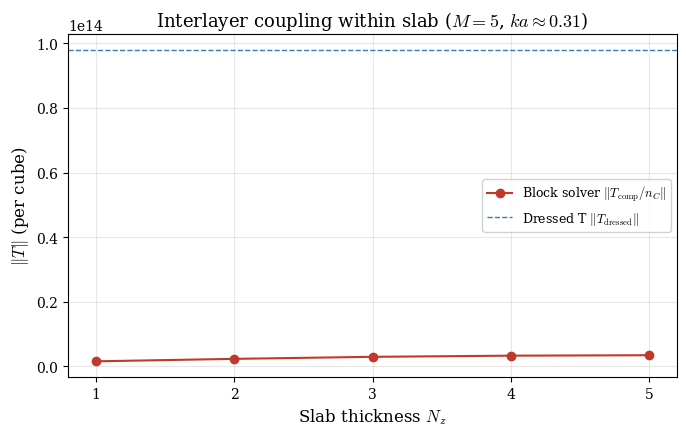

In [7]:
M_fixed = 5
Nz_vals = [1, 2, 3, 4, 5]
T_norms = []

print(f"Thickness sweep (M={M_fixed}, moderate contrast):")
for Nz in Nz_vals:
    T_comp, nC, nL, iters = solve_slab_foldy_lax(
        M_fixed, Nz, a, omega_test, ref, contrast_mod,
    )
    T_per_cube = T_comp / nC
    T_norms.append(np.linalg.norm(T_per_cube))
    print(
        f"  N_z={Nz}: {nC:3d} cubes, {nL} layers, {iters:3d} iters, "
        f"\u2016T_comp/nC\u2016 = {T_norms[-1]:.4e}"
    )

T_dressed_mod_norm = np.linalg.norm(T_dressed_mod)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(Nz_vals, T_norms, "o-", color=RED, markersize=6, linewidth=1.5,
        label=r"Block solver $\|T_{\mathrm{comp}}/n_C\|$")
ax.axhline(T_dressed_mod_norm, color=BLUE, linestyle="--", linewidth=1.0,
           label=r"Dressed T $\|T_{\mathrm{dressed}}\|$")
ax.set_xlabel(r"Slab thickness $N_z$")
ax.set_ylabel(r"$\|T\|$ (per cube)")
ax.set_title(rf"Interlayer coupling within slab ($M={M_fixed}$, $ka \approx {ka:.2f}$)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(Nz_vals)
fig.tight_layout()
plt.show()

## 5. Reflectivity: Bare vs Dressed T in the Marine Model

We feed the bare and dressed T-matrices (hard contrast) into the
Riccati interlayer solver as scatterers at interfaces 1 and 2, and
compute ocean-bottom reflectivity as a function of frequency.

The dressed T captures intra-layer multiple scattering that the bare T
ignores.  This uses only the dressed T-matrix computation (lattice
self-energy), not the full block solver.

In [8]:
freqs = np.linspace(2.0, 30.0, 25)
kx_fixed = np.array([3.0])
ky_fixed = np.array([0.0])

R_bg = np.zeros(len(freqs), dtype=complex)
R_bare_total = np.zeros(len(freqs), dtype=complex)
R_dressed_total = np.zeros(len(freqs), dtype=complex)

print("Reflectivity sweep (hard contrast, bare vs dressed T):")
for i, freq in enumerate(freqs):
    omega_c = 2 * np.pi * freq + 0.1j

    # Bare T
    T_bare_i = compute_slab_tmatrices(geom_1, mat_hard, omega_c)[0, 0, 0]

    # Dressed T
    T_dressed_i = dressed_layer_tmatrix(a, ref, contrast_hard, omega_c, n_rings=20)

    # Riccati with bare T
    slab_bare = ScattererSlab9x9(
        model=model,
        scatterer_ifaces=[1, 2],
        tmatrices={1: T_bare_i, 2: T_bare_i},
        number_densities={1: n_density, 2: n_density},
    )
    res_bare = interlayer_ms_reflectivity_9x9(
        slab_bare, omega_c, kx_fixed, ky_fixed,
    )
    R_bg[i] = res_bare.R_background[0]
    R_bare_total[i] = res_bare.R_total[0]

    # Riccati with dressed T
    slab_dressed = ScattererSlab9x9(
        model=model,
        scatterer_ifaces=[1, 2],
        tmatrices={1: T_dressed_i, 2: T_dressed_i},
        number_densities={1: n_density, 2: n_density},
    )
    res_dressed = interlayer_ms_reflectivity_9x9(
        slab_dressed, omega_c, kx_fixed, ky_fixed,
    )
    R_dressed_total[i] = res_dressed.R_total[0]

    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(freqs)} frequencies done")

print("Done.")

Reflectivity sweep (hard contrast, bare vs dressed T):
  5/25 frequencies done
  10/25 frequencies done
  15/25 frequencies done
  20/25 frequencies done
  25/25 frequencies done
Done.


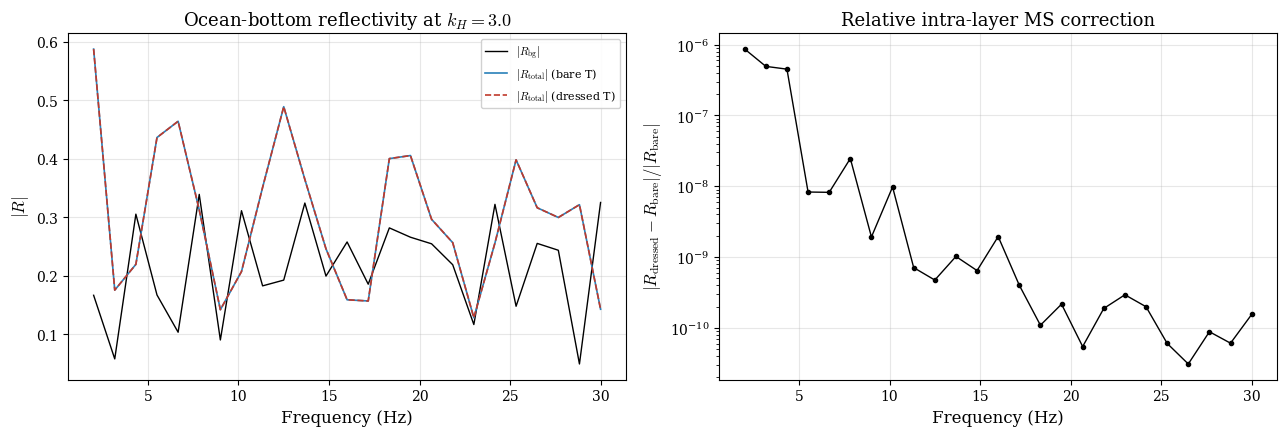

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: absolute reflectivities
axes[0].plot(freqs, np.abs(R_bg), color="black", linewidth=1.0,
             label=r"$|R_{\mathrm{bg}}|$")
axes[0].plot(freqs, np.abs(R_bare_total), color=BLUE, linewidth=1.2,
             label=r"$|R_{\mathrm{total}}|$ (bare T)")
axes[0].plot(freqs, np.abs(R_dressed_total), color=RED, linewidth=1.2,
             linestyle="--", label=r"$|R_{\mathrm{total}}|$ (dressed T)")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel(r"$|R|$")
axes[0].set_title(r"Ocean-bottom reflectivity at $k_H = 3.0$")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: relative correction from dressing
rel_diff = (
    np.abs(R_dressed_total - R_bare_total)
    / np.maximum(np.abs(R_bare_total), 1e-30)
)
axes[1].semilogy(freqs, rel_diff, "o-", color="black", markersize=3,
                 linewidth=1.0)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel(
    r"$|R_{\mathrm{dressed}} - R_{\mathrm{bare}}|"
    r" / |R_{\mathrm{bare}}|$"
)
axes[1].set_title("Relative intra-layer MS correction")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Summary

| Experiment | Key result |
|---|---|
| Block solver validation | Matches dense reference solve to $< 10^{-8}$ relative error |
| Slab thickness sweep | Interlayer coupling within slab modifies per-cube T |
| Reflectivity (bare vs dressed) | Dressed T shifts reflectivity by capturing intra-layer MS |

The block solver (2D FFT convolution + GMRES) correctly reproduces the
exact Foldy-Lax solution for finite slabs of heterogeneous cubes.
The dressed T-matrix provides a practical drop-in replacement for the
bare T in the Riccati interlayer solver, capturing the dominant
intra-layer MS correction without the cost of a full Foldy-Lax solve.